# Tutorial: Fluorescence correlation spectroscopy

In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import matplotlib.pyplot as plt
import src.figures as fi
import src.custom_plot as cp
import src.fluorophore_systems as fs
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

In [21]:
transitions = [['S0_S1', 7e6, "excitation", "EXC", False],  
               ['S1_S0', 1e9, "fluorescent emission", "FLU", True], 
               ['S1_T1', 1e6, "intersystem crossing ST", "ISCST", False],   
               ['T1_S0', 5e5, "intersystem crossing TS", "ISCTS", False]]

In [22]:
system = fs.FluorophoreSystem(number_fluorophores=5, distances=1, transitions=transitions)

In [23]:
system.simulate(n_steps=10000000, seed=99)

In [24]:
system.process()

### The deltat paramater
The method 'emitters()' call resamples the time points into constant time steps, which resembles the time interval of frames of a camera. However, the method fcs() call can introduce a different time step with the deltat parameter.

In [25]:
system.emitters(photon_collection_rate=1, resample="1ms", emccd_gain=100,
                threshold=0, memory=0, remove_heading_off_period=False, 
                seed=100)

In [27]:
system.fcs(normalize=True, log=True, m=4, deltat='1ms')
original_time_step_data = system.autocorrelation
series_1 = system.event_time_series

For example, here we resample with 1 ms. The FCS curve (red) doesn't reveal much, because the time step is too large, the interesting kinetics happen on a smaller timescale (in this case). Hence, we use a smaller $\tau$ value.

In [28]:
system.fcs(normalize=True, log=True, m=4, deltat='1us')
new_time_step_data = system.autocorrelation
series_2 = system.event_time_series

The pandas_series attribute is not altered, only the autocorrelation attribute is. 

In [29]:
series_1.equals(series_2)

True

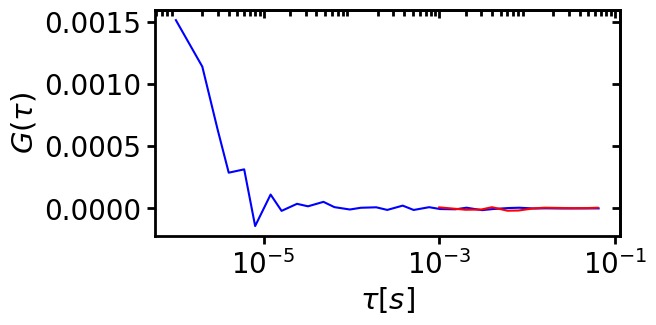

In [30]:
fig, ax = system.plot.fcs(normalize_to=None, unit="s", title=None)
ax[0, 0].plot(original_time_step_data[0][1:], original_time_step_data[1][1:], color="r")

### The m parameter
The m parameter assumes the log parameter to be set to True, which should always be the case since it largely lowers computation resources. The m parameter determines, how accurate the result is - smaller m have less values computed. The multipletau package autocorrelates the data on a $\log_2$ scale. The levels are therefore 1, 2, 4, 8, 16, 32, ... . The m parameter defines the number of points on each level: m=2 leads to 1, 2, 4, 8, 16, 32, ...; m=4 leads to 1, 2, 3, 4 + 2, 4, 6, 8 + 4, 8, 12, 16 + 8, 16, 24, 32 &#8594; 1, 2, 3, 4, 6, 8, 12, 16, 24, 32, ... .

## log = False

In [32]:
system.fcs(normalize=True, log=False, m=4, deltat='1us')
autocor_lin = system.autocorrelation

In [33]:
system.fcs(normalize=True, log=True, m=4, deltat='1us')
autocor_log = system.autocorrelation

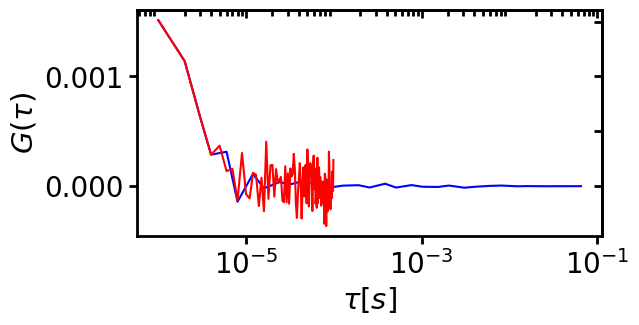

In [34]:
fig, ax = system.plot.fcs(normalize_to=None, unit="s", title=None)
ax[0, 0].plot(autocor_lin[0][1:100], autocor_lin[1][1:100], color="r")

The linear autocorrelation has much more values computed but these rarely matter since the very small, few time steps at the very beginning are of most interest. As the time steps increase, the correlation signal is getting noisier and is no longer useful, fluctuating around 0.

### Normalize = False

In [35]:
system.fcs(normalize=False, log=False, m=4, deltat='1us')
autocor_lin = system.autocorrelation

In [36]:
system.fcs(normalize=False, log=True, m=4, deltat='1us')
autocor_log = system.autocorrelation

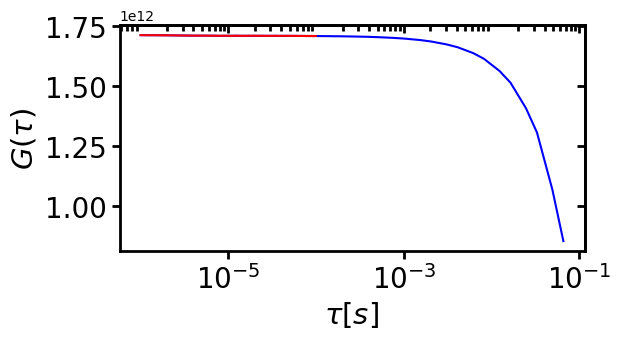

In [17]:
fig, ax = system.plot.fcs(normalize_to=None, unit="s", title=None)
ax[0, 0].plot(autocor_lin[0][1:100], autocor_lin[1][1:100], color="r")

In [245]:
def autocorrelate(array, m, tau, normalize):
    dtype = np.float64
    array = np.array(array, dtype=dtype, copy=True)
    
    n = n0 = array.shape[0]  # length of the input array

    levels = np.int_(np.floor(np.log2(n/m)))

    # n/m because the last entry, n, is (at least nearly) reached with the m-th of n/m
    # e.g., n = 2400, m = 4 -> n/m = 600 -> 2**levels =~ 600 -> m1, m2, m3, m4 = 600, 1200, 1800, 2400 

    lenG = m + levels * (m//2) + 1  # theoretical lenght of the correlation array (can still change)
    # // is floor division    
    
    G = np.zeros((lenG, 2), dtype=dtype)
    
    normstat = np.zeros(lenG, dtype=dtype)  # normalization to number of entries correlated 
    # equivalent to correl = np.divide(correl, np.arange(correl.size, 0, -1))
    
    normnump = np.zeros(lenG, dtype=dtype)

    mean = np.average(array)
    
    if normalize:
        array = array - mean  # subtract the mean value from the data points to receive the deviations
    
    # first m+1 elements of G (0, 1, 2, ..., m)
    # resembles level 0 (2^0 = 1)
    # special because it also contains level_point 0
    for level_point in range(0, m + 1):
        G[level_point, 0] = tau * level_point  # the time differences
        G[level_point, 1] = np.sum(array[:n - level_point] * array[level_point:])  # cross correlation is multiplication and summation
        
        normstat[level_point] = n - level_point  # the number of entries correlated
        normnump[level_point] = n
    
    if n % 2 == 1:  # if the length of the input array is not even, make it even
        n = n - 1
        
    # averaging every 2 elements
    array = (array[:n:2] + array[1:n:2]) / 2
    # due to the averaging step, the length of array is now half it was before
    n = n//2  # floor division just to make it an integer

    for level in range(1, levels + 1):  # iteration through every level
        for level_point in range(1, m//2 + 1):  # iteration through every (additional) m in each level
            # note the m//2 is because only half of m values in each level is additional
            # the other half is already there due to the levels and m's before
            # e.g., m = 6: 0, 1, 2, 3, 4, 5, 6,
            #              2, 4, 6, 8, 10, 12 (new: 8, 10, 12)
            #              4, 8, 12, 16, 20, 24 (new: 16, 20, 24)
            
            idx_array = level_point + m//2  # index of interest of the (current) averaged array
            # e.g., if m = 6, the first idx_array is 4 
            # level 0 already covered entry 0, 1, 2, 3, 4, 5, 6
            # the first averaged array is 0(0, 1), 1(2, 3), 2(4, 5), 3(6, 7), 4(8, 9), ...
            # hence, the idx_array of 4 contains the 8th entry 
            
            # the second averaged array is 0(0, 1, 2, 3), 1(4, 5, 6, 7), 2(8, 9, 10, 11), 3(12, 13, 14, 15),
            # 4(16, 17, 18, 19), ... hence, the idx_array of 4 contains the 12th entry
            idx_G = m + level_point + (level-1) * m//2 
            
            if len(array[:n - idx_array]) == 0:
                G = G[:idx_G - 1]
                
                normstat = normstat[:idx_G - 1]
                normnump = normnump[:idx_G - 1]
                
                break
            else:
                G[idx_G, 0] = tau * idx_array * 2**level
                G[idx_G, 1] = np.sum(array[:n - idx_array] * array[idx_array:])
                
                normstat[idx_G] = n - idx_array
                normnump[idx_G] = n
    
        if n % 2 == 1:
            n -= 1
        array = (array[:n:2] + array[1:n:2]) / 2
        
        n //= 2
    
    if normalize:
        G[:, 1] /= mean**2 * normstat
    else:
        G[:, 1] *= n0 / normnump

    return G
    

## Pycorrelate

In [2]:
import src.fcs as f

In [4]:
transitions = [['S0_S1', 7e6, "excitation", "EXC", False],  
               ['S1_S0', 1e9, "fluorescent emission", "FLU", True], 
               ['S1_T1', 1e6, "intersystem crossing ST", "ISCST", False],   
               ['T1_S0', 5e5, "intersystem crossing TS", "ISCTS", False]]

In [11]:
system = fs.FluorophoreSystem(number_fluorophores=4, distances=1, transitions=transitions)

In [12]:
system.simulate(n_steps=1000000, seed=99)

In [15]:
system.process()

In [18]:
system.emitters(photon_collection_rate=1, resample="1 us", emccd_gain=100,
                threshold=0, memory=0, remove_heading_off_period=False, 
                seed=100)

In [66]:
tau, autocorr = f.autocorrelate_time_points(system.time_points_events, exp_min=-8, exp_max=-2, base=10, normalize=False)

In [67]:
import matplotlib.pyplot as plt

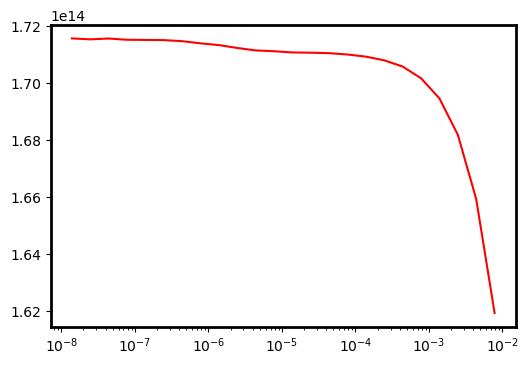

In [68]:
plt.plot(tau, autocorr, color="r")
plt.xscale('log')

In [17]:
bins, autocorr = f.autocorrelate_time_points(system.time_points_events, bin_limits=[-8, -3], normalize=True)

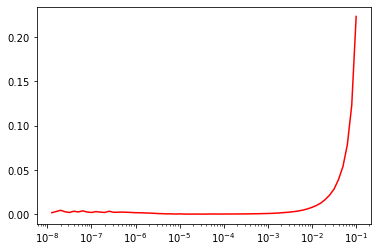

In [19]:
plt.plot(bins[1:], autocorr-1, color="r")
plt.xscale('log')